In [1]:
# Load the libraries

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Show 
print("PyTorch version: {}".format(torch.__version__))

SEED = int(time.time())

PyTorch version: 2.5.1+cu121


In [2]:
# Setup device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device} is in use")

cuda is in use


### Uploading the data from .csv file

In [3]:
# Read CSV file
df = pd.read_csv("Titanic_Dataset.csv")

# Show information about the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Data Cleaning

In [4]:
# delete Cabin column - contains moslty NaN values
df.drop(columns=['Cabin'], inplace=True)

# delete other rows that contain NaNs; here mostly for the Age column but still there should enough data to run training
df.dropna(axis='index', how='any', inplace=True)

# calculate Passangers' family sizes aboard the ship
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# drop redundant data
df.drop(columns=["Name", "SibSp", "Parch", "Ticket", "Embarked"], inplace=True)

# for later training I've mapped male to value '0' and female to '1'
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Sex          712 non-null    int64  
 4   Age          712 non-null    float64
 5   Fare         712 non-null    float64
 6   FamilySize   712 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 44.5 KB


### Simple analysis

In [6]:
# beakdown by classes
df_class = df.groupby("Pclass")["Survived"].mean()
print(df_class)

Pclass
1    0.652174
2    0.479769
3    0.239437
Name: Survived, dtype: float64


In [7]:
# beakdown by sexes
df_sex = df.groupby("Sex")["Survived"].mean()
print(df_sex)

Sex
0    0.205298
1    0.752896
Name: Survived, dtype: float64


In [8]:
# beakdown by FamilySize   
df_famsize = df.groupby("FamilySize")["Survived"].mean()
print(df_famsize)

FamilySize
1    0.318408
2    0.546763
3    0.569892
4    0.777778
5    0.272727
6    0.136364
7    0.333333
8    0.000000
Name: Survived, dtype: float64


## Machine learning

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [10]:
X = df[["Pclass", "Sex", "Age", "Fare", "FamilySize"]]
y = df["Survived"]

In [11]:
X = X.to_numpy()
y = y.to_numpy()

In [12]:
print( np.shape(X) )
print( np.shape(y) )

(712, 5)
(712,)


In [13]:
X_tensor = torch.from_numpy(X).type(torch.float)
y_tensor = torch.from_numpy(y).type(torch.float)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_tensor,
                                                    y_tensor,
                                                    test_size=0.15,
                                                    random_state=SEED)

### scikit.learn functions

In [15]:
### using predefined LogisticRegression from scikit.learn library

clf = LogisticRegression(max_iter=1000, random_state=SEED)
clf.fit(X_train, y_train)

acc = accuracy_score(y_test, clf.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 77.57%


### PyTorch

In [16]:
def acc_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = 100*correct/len(y_pred)
    return acc

In [17]:
###  model initialization

class Titanic_Model_v1(nn.Module):

    def __init__(self, input_features, hidden_layers, output_features):
        super().__init__()

        self.linear_layers_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_layers),
            nn.ReLU(),
            nn.Linear(in_features=hidden_layers, out_features=hidden_layers),
            nn.ReLU(),
            nn.Linear(in_features=hidden_layers, out_features=hidden_layers),
            nn.ReLU(),
            nn.Linear(in_features=hidden_layers, out_features=output_features)
        )


    def forward(self, x):
        return self.linear_layers_stack(x)

In [19]:
### setting up the training

torch.manual_seed( SEED )
torch.cuda.manual_seed( SEED )

epochs = 1001

X_train, y_train = X_train.to(device), y_train.to(device)
X_test,  y_test  = X_test.to(device),  y_test.to(device)

train_loss_dis = np.zeros(epochs)
test_loss_dis = np.zeros(epochs)



model_1 = Titanic_Model_v1(input_features=5, 
                          hidden_layers=16, 
                          output_features=1).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                            lr=0.003)



for epoch in range(epochs):

    ### TRAINING

    model_1.train()

    y_logits = model_1(X_train)
    y_pred = (torch.sigmoid(y_logits) > 0.5).float()

    train_loss = loss_fn(y_logits, y_train.unsqueeze(1))
    acc = acc_fn(y_train, y_pred.squeeze(1))

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    ### TESTING

    model_1.eval()

    with torch.inference_mode():

        test_logits = model_1(X_test)
        test_pred =  (torch.sigmoid(test_logits) > 0.5).float()

        test_loss = loss_fn(test_logits, y_test.unsqueeze(1))
        test_acc = acc_fn(y_test, test_pred.squeeze(1))

        train_loss_dis[epoch] = train_loss
        test_loss_dis[epoch] = test_loss

        if epoch > 1 and epoch%int(epochs/10) == 0:
            print(f"Epoch: {epoch} | Loss: {train_loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")   

Epoch: 100 | Loss: 0.53647, Acc: 71.40% | Test Loss: 0.63274, Test Acc: 68.22%
Epoch: 200 | Loss: 0.41611, Acc: 79.50% | Test Loss: 0.47589, Test Acc: 78.50%
Epoch: 300 | Loss: 0.40434, Acc: 81.49% | Test Loss: 0.47626, Test Acc: 79.44%
Epoch: 400 | Loss: 0.39991, Acc: 82.64% | Test Loss: 0.47509, Test Acc: 79.44%
Epoch: 500 | Loss: 0.39714, Acc: 82.64% | Test Loss: 0.47532, Test Acc: 79.44%
Epoch: 600 | Loss: 0.39561, Acc: 83.31% | Test Loss: 0.47837, Test Acc: 79.44%
Epoch: 700 | Loss: 0.39110, Acc: 82.64% | Test Loss: 0.47562, Test Acc: 81.31%
Epoch: 800 | Loss: 0.38347, Acc: 84.30% | Test Loss: 0.47564, Test Acc: 80.37%
Epoch: 900 | Loss: 0.37678, Acc: 84.63% | Test Loss: 0.47957, Test Acc: 79.44%
Epoch: 1000 | Loss: 0.37443, Acc: 84.46% | Test Loss: 0.48381, Test Acc: 77.57%


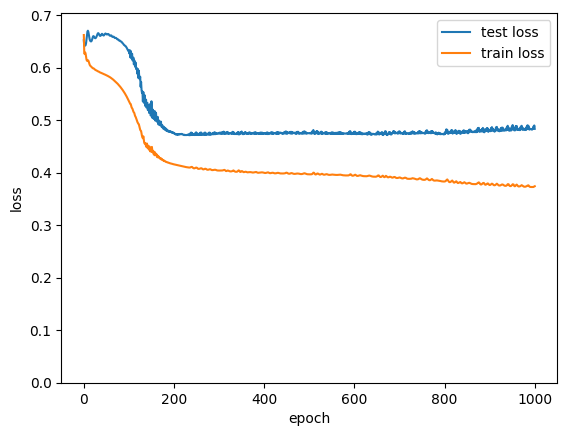

In [20]:
plt.plot(range(epochs), test_loss_dis, label="test loss" )
plt.plot(range(epochs), train_loss_dis, label="train loss" )
plt.ylim(0, 1.05*np.concatenate( (test_loss_dis, train_loss_dis) ).max() )
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()